# Sesión 4 – Estrategias de Reemplazo Generacional

Cuaderno de apuntes completo para comprender cómo sobreviven los individuos en algoritmos genéticos.

## 1. Motivación

No basta con generar hijos: es fundamental decidir quién sobrevive. Esta sesión analiza las principales estrategias de reemplazo generacional.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random


## 2. Problema base

Usamos el TSP como problema común para comparar estrategias.

In [2]:
num_ciudades = 16
ciudades = np.random.rand(num_ciudades, 2)


In [3]:
def distancia_total(ruta, ciudades):
    d = 0
    for i in range(len(ruta)):
        a = ciudades[ruta[i]]
        b = ciudades[ruta[(i+1)%len(ruta)]]
        d += np.linalg.norm(a-b)
    return d


In [4]:
def poblacion_inicial(n, m):
    return [np.random.permutation(m) for _ in range(n)]


In [5]:
def seleccion_torneo(p, c, k=3):
    t = random.sample(p, k)
    t.sort(key=lambda r: distancia_total(r, c))
    return t[0]


In [6]:
def cruce_ox(p1, p2):
    s = len(p1)
    a, b = sorted(random.sample(range(s), 2))
    h = [-1]*s
    h[a:b] = p1[a:b]
    pos = b
    for g in p2:
        if g not in h:
            if pos >= s: pos = 0
            h[pos] = g
            pos += 1
    return np.array(h)


In [7]:
def mutacion_swap(r, p=0.2):
    r = r.copy()
    if random.random() < p:
        i, j = random.sample(range(len(r)), 2)
        r[i], r[j] = r[j], r[i]
    return r


## 3. Estrategias de reemplazo

Analizamos cuatro estrategias: reemplazo generacional completo, elitismo, (μ + λ) y steady-state.

### Estrategia 1: Reemplazo generacional completo

Toda la población es sustituida por hijos en cada generación.

In [8]:
def gen_completo(p, N):
    return [mutacion_swap(cruce_ox(seleccion_torneo(p, ciudades), seleccion_torneo(p, ciudades))) for _ in range(N)]


### Estrategia 2: Elitismo

El mejor individuo de la generación siempre sobrevive.

In [9]:
def gen_elitista(p, N):
    mejor = min(p, key=lambda r: distancia_total(r, ciudades))
    nueva = [mejor]
    while len(nueva) < N:
        nueva.append(mutacion_swap(cruce_ox(seleccion_torneo(p, ciudades), seleccion_torneo(p, ciudades))))
    return nueva


### Estrategia 3: Modelo (μ + λ)

Padres e hijos compiten juntos por sobrevivir.

In [10]:
def modelo_mu_mas_lambda(poblacion, mu, lambd):
    hijos = []
    for _ in range(lambd):
        p1 = seleccion_torneo(poblacion, ciudades)
        p2 = seleccion_torneo(poblacion, ciudades)
        hijos.append(mutacion_swap(cruce_ox(p1, p2)))
    total = poblacion + hijos
    total.sort(key=lambda r: distancia_total(r, ciudades))
    return total[:mu]


### Estrategia 4: Steady-State

La población se modifica gradualmente eliminando solo los peores individuos.

In [11]:
def steady(p, k=2):
    for _ in range(k):
        h = mutacion_swap(cruce_ox(seleccion_torneo(p, ciudades), seleccion_torneo(p, ciudades)))
        p.append(h)
        p.sort(key=lambda r: distancia_total(r, ciudades))
        p.pop()
    return p


## 4. Experimento comparativo

Ejecutamos cada estrategia y analizamos la convergencia.

In [12]:
def ejecutar(estr, gen=1000, N=40):
    p = poblacion_inicial(N, num_ciudades)
    hist = []
    for _ in range(gen):
        if estr == 'completo': p = gen_completo(p, N)
        if estr == 'elitista': p = gen_elitista(p, N)
        if estr == 'modelo_mu_mas_lambda': p = modelo_mu_mas_lambda(p, N, N)
        if estr == 'steady': p = steady(p)
        hist.append(distancia_total(min(p, key=lambda r: distancia_total(r, ciudades)), ciudades))
    return hist


In [13]:
h1 = ejecutar('completo')
h2 = ejecutar('elitista')
h3 = ejecutar('modelo_mu_mas_lambda')
h4 = ejecutar('steady')


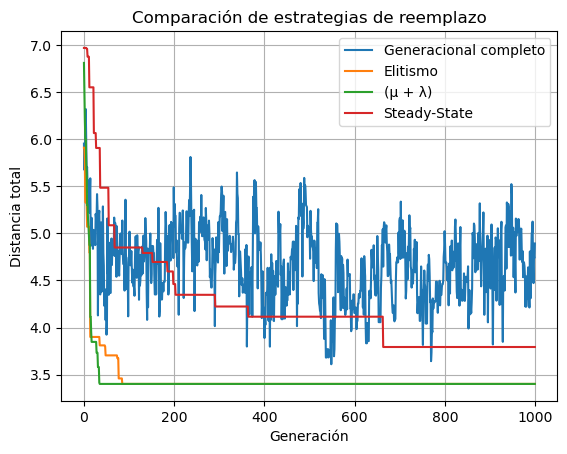

In [14]:
plt.plot(h1, label='Generacional completo')
plt.plot(h2, label='Elitismo')
plt.plot(h3, label='(μ + λ)')
plt.plot(h4, label='Steady-State')
plt.legend(); plt.grid(True)
plt.xlabel('Generación'); plt.ylabel('Distancia total')
plt.title('Comparación de estrategias de reemplazo'); plt.show()


## 5. Conclusiones

El modelo de reemplazo afecta profundamente al comportamiento del algoritmo. Diseñar un AG implica elegir conscientemente esta estrategia.